<a href="https://colab.research.google.com/github/IsabelaNeves1/am-t4-s1a2026/blob/main/prova20_isabela_neves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AVA 2 - CONSULTORIA DE INTELIGÊNCIA ARTIFICIAL
# ANAC - PREVISÃO DE ATRASOS DE VOOS
# Aluna: Isabela Neves da Silva

## Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.utils import resample


In [2]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier


# FASE 1 - EXTRAÇÃO

In [6]:
df = pd.read_csv(
    'VRA_2025_04.csv',
    sep=';',
    encoding='utf-8'
)

/tmp/ipykernel_5658/483349954.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [7]:
df.columns.tolist()

['Sigla ICAO Empresa Aérea',
 'Empresa Aérea',
 'Número Voo',
 'Código DI',
 'Código Tipo Linha',
 'Modelo Equipamento',
 'Número de Assentos',
 'Sigla ICAO Aeroporto Origem',
 'Descrição Aeroporto Origem',
 'Partida Prevista',
 'Partida Real',
 'Sigla ICAO Aeroporto Destino',
 'Descrição Aeroporto Destino',
 'Chegada Prevista',
 'Chegada Real',
 'Situação Voo',
 'Justificativa',
 'Referência',
 'Situação Partida',
 'Situação Chegada']

# FASE 2 - TRATAMENTO

## Conversão das datas brasileiras

In [8]:
df['Partida Prevista'] = pd.to_datetime(
    df['Partida Prevista'],
    dayfirst=True,
    errors='coerce'
)

df['Partida Real'] = pd.to_datetime(
    df['Partida Real'],
    dayfirst=True,
    errors='coerce'
)

## Remover registros sem datas necessárias


In [9]:
df.dropna(
    subset=[
        'Partida Prevista',
        'Partida Real'
    ],
    inplace=True
)

## FEATURE PRINCIPAL DA PROVA(desafio)

In [10]:
df['Minutos_Atraso'] = (
    df['Partida Real']
    -
    df['Partida Prevista']
).dt.total_seconds()/60

## Feature adicional - Atraso em cascata (Voo Anterior)

In [11]:
df = df.sort_values(
    by=['Sigla ICAO Empresa Aérea', 'Número Voo', 'Partida Prevista']
).reset_index(drop=True)

df['Atraso_Voo_Anterior'] = (
    df.groupby(['Sigla ICAO Empresa Aérea', 'Número Voo'])['Minutos_Atraso']
    .shift(1)
)

df['Tem_Voo_Anterior'] = df['Atraso_Voo_Anterior'].notna().astype(int)
df['Atraso_Voo_Anterior'] = df['Atraso_Voo_Anterior'].fillna(0)

## Features de tempo


In [12]:
df['Hora'] = (
    df['Partida Prevista']
    .dt.hour
)

df['Dia_Semana'] = (
    df['Partida Prevista']
    .dt.dayofweek
)

df['Mes'] = (
    df['Partida Prevista']
    .dt.month
)

df['Dia_Mes'] = (
    df['Partida Prevista']
    .dt.day
)

df['Fim_Semana'] = (
    df['Partida Prevista']
    .dt.dayofweek >= 5
).astype(int)

df['Periodo'] = pd.cut(
    df['Hora'],
    bins=[-1, 6, 12, 18, 23],
    labels=[
        'Madrugada',
        'Manha',
        'Tarde',
        'Noite'
    ]
)

## Tratamento de nulos para preditores númericos

In [13]:
df['Número de Assentos'] = df['Número de Assentos'].fillna(df['Número de Assentos'].median())

## CRIAÇÃO DO Y

In [14]:
df['Y_Atrasado'] = (
    df['Minutos_Atraso'] > 30
).astype(int)

## Redução de dimensionalidade estratégica para evitar estouro de memória na MLP

In [15]:
top_empresas = df['Empresa Aérea'].value_counts().index[:15]
df['Empresa Aérea'] = df['Empresa Aérea'].apply(lambda x: x if x in top_empresas else 'Outros')

top_origens = df['Sigla ICAO Aeroporto Origem'].value_counts().index[:15]
df['Sigla ICAO Aeroporto Origem'] = df['Sigla ICAO Aeroporto Origem'].apply(lambda x: x if x in top_origens else 'Outros')

top_destinos = df['Sigla ICAO Aeroporto Destino'].value_counts().index[:15]
df['Sigla ICAO Aeroporto Destino'] = df['Sigla ICAO Aeroporto Destino'].apply(lambda x: x if x in top_destinos else 'Outros')

top_equipamentos = df['Modelo Equipamento'].value_counts().index[:15]
df['Modelo Equipamento'] = df['Modelo Equipamento'].apply(lambda x: x if x in top_equipamentos else 'Outros')

##Visualização do desbalanceamento

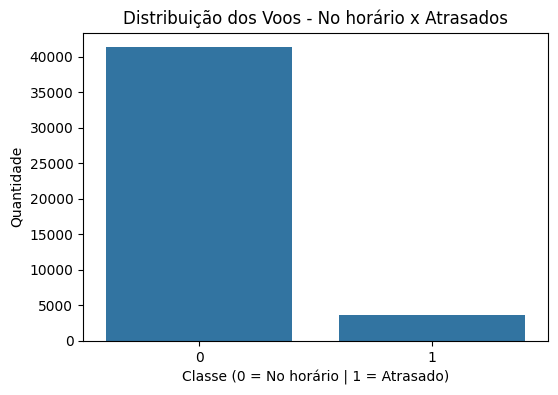

In [16]:
plt.figure(figsize=(6,4))


sns.countplot(
    data=df,
    x='Y_Atrasado'
)


plt.title(
    "Distribuição dos Voos - No horário x Atrasados"
)


plt.xlabel(
    "Classe (0 = No horário | 1 = Atrasado)"
)


plt.ylabel(
    "Quantidade"
)


plt.show()

#FASE 3 — ONE HOT ENCODING

(Correção da AVA 1)

In [17]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        'Empresa Aérea',
        'Sigla ICAO Aeroporto Origem',
        'Sigla ICAO Aeroporto Destino',
        'Modelo Equipamento',
        'Código Tipo Linha',
        'Periodo'
    ],
    drop_first=True,
    dtype=int
)

features_empresa = [coluna for coluna in df_encoded.columns if "Empresa Aérea_" in coluna]
features_origem = [coluna for coluna in df_encoded.columns if "Sigla ICAO Aeroporto Origem_" in coluna]
features_destino = [coluna for coluna in df_encoded.columns if "Sigla ICAO Aeroporto Destino_" in coluna]
features_equipamento = [coluna for coluna in df_encoded.columns if "Modelo Equipamento_" in coluna]
features_tipo_linha = [coluna for coluna in df_encoded.columns if "Código Tipo Linha_" in coluna]
features_periodo = [coluna for coluna in df_encoded.columns if "Periodo_" in coluna]

## DEFINIÇÃO DOS PREDITORES

In [18]:
features = [
    'Hora',
    'Dia_Semana',
    'Dia_Mes',
    'Mes',
    'Fim_Semana',
    'Número de Assentos',
    'Atraso_Voo_Anterior',
    'Tem_Voo_Anterior'
] + features_empresa + features_origem + features_destino + features_equipamento + features_tipo_linha + features_periodo

df_encoded = df_encoded.dropna(
    subset=features + ['Y_Atrasado']
)

X = df_encoded[features]
y = df_encoded['Y_Atrasado']

## DIVISÃO TREINO E TESTE
## ANTES DO BALANCEAMENTO

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## BALANCEAMENTO DA CLASSE MINORITÁRIA
## SOMENTE TREINO

In [20]:
train_data = pd.concat(
    [
        X_train,
        y_train
    ],
    axis=1
)

classe_0 = train_data[train_data.Y_Atrasado == 0]
classe_1 = train_data[train_data.Y_Atrasado == 1]

classe_1_up = resample(
    classe_1,
    replace=True,
    n_samples=len(classe_0),
    random_state=42
)

df_train_balanced = pd.concat(
    [
        classe_0,
        classe_1_up
    ]
)

X_train_balanced = df_train_balanced.drop('Y_Atrasado', axis=1)
y_train_balanced = df_train_balanced['Y_Atrasado']

## NORMALIZAÇÃO
## SOMENTE TREINO

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

## Avaliação dos modelos

In [22]:
resultados = []

def avaliar(nome, modelo, Xteste, yteste):
    previsao = modelo.predict(Xteste)
    print("="*60)
    print(nome)
    print("="*60)
    print(classification_report(yteste, previsao))

    matriz = confusion_matrix(yteste, previsao)
    sns.heatmap(matriz, annot=True, fmt='d')
    plt.title("Matriz de Confusão - " + nome)
    plt.xlabel("Previsto")
    plt.ylabel("Real")
    plt.show()

    resultados.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(yteste, previsao),
        "Precision": precision_score(yteste, previsao, zero_division=0),
        "Recall": recall_score(yteste, previsao),
        "F1": f1_score(yteste, previsao)
    })

# PIPELINE 2 - DECISION TREE

PIPELINE 2 - DECISION TREE
Decision Tree
              precision    recall  f1-score   support

           0       0.94      0.68      0.79      8266
           1       0.13      0.55      0.21       736

    accuracy                           0.67      9002
   macro avg       0.54      0.61      0.50      9002
weighted avg       0.88      0.67      0.74      9002



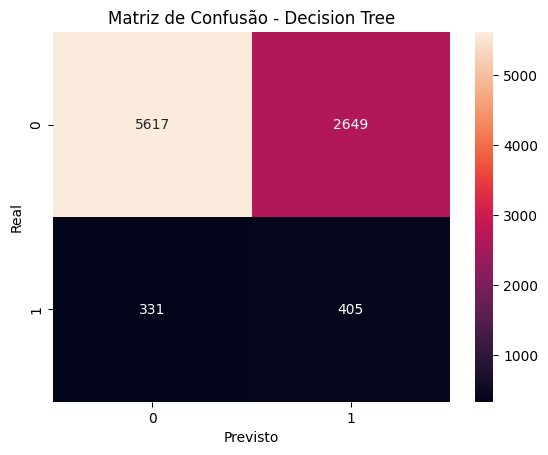

In [23]:
print("PIPELINE 2 - DECISION TREE")
modelo_dt = DecisionTreeClassifier(max_depth=6, min_samples_split=10, random_state=42)
modelo_dt.fit(X_train_balanced, y_train_balanced)
avaliar("Decision Tree", modelo_dt, X_test, y_test)

# PIPELINE 3 - RANDOM FOREST

PIPELINE 3 - RANDOM FOREST
Random Forest
              precision    recall  f1-score   support

           0       0.94      0.72      0.82      8266
           1       0.14      0.52      0.22       736

    accuracy                           0.70      9002
   macro avg       0.54      0.62      0.52      9002
weighted avg       0.88      0.70      0.77      9002



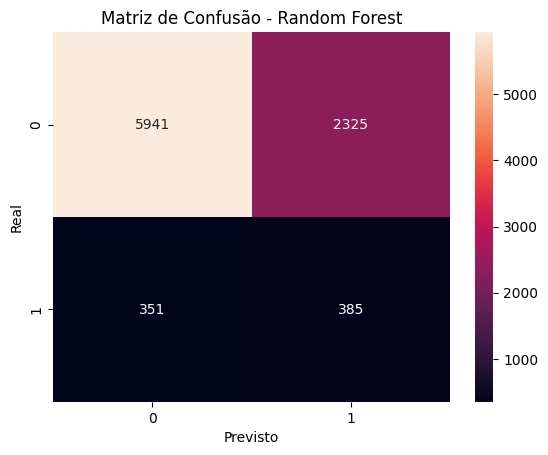

In [24]:
print("PIPELINE 3 - RANDOM FOREST")
modelo_rf = RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train_balanced, y_train_balanced)
avaliar("Random Forest", modelo_rf, X_test, y_test)

# PIPELINE 4 - SUPPORT VECTOR MACHINE

PIPELINE 4 - SUPPORT VECTOR MACHINE
SVM
              precision    recall  f1-score   support

           0       0.94      0.62      0.75      8266
           1       0.12      0.57      0.19       736

    accuracy                           0.61      9002
   macro avg       0.53      0.59      0.47      9002
weighted avg       0.87      0.61      0.70      9002



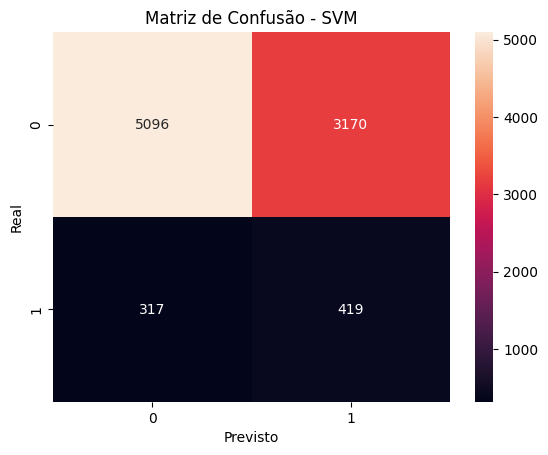

In [25]:
print("PIPELINE 4 - SUPPORT VECTOR MACHINE")
modelo_svm = LinearSVC(C=0.1, random_state=42, max_iter=2000, dual=False)
modelo_svm.fit(X_train_scaled, y_train_balanced)
avaliar("SVM", modelo_svm, X_test_scaled, y_test)

# PIPELINE 5 - KNN

PIPELINE 5 - KNN
KNN
              precision    recall  f1-score   support

           0       0.93      0.74      0.83      8266
           1       0.12      0.40      0.19       736

    accuracy                           0.71      9002
   macro avg       0.53      0.57      0.51      9002
weighted avg       0.87      0.71      0.77      9002



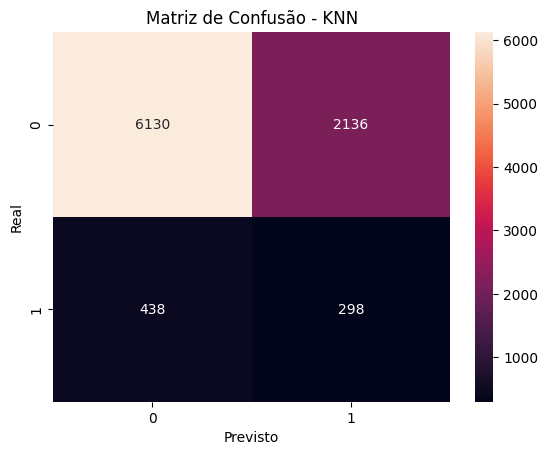

In [26]:
print("PIPELINE 5 - KNN")
modelo_knn = KNeighborsClassifier(n_neighbors=7, n_jobs=-1)
modelo_knn.fit(X_train_scaled, y_train_balanced)
avaliar("KNN", modelo_knn, X_test_scaled, y_test)

# PIPELINE 6 - REDE NEURAL MLP

PIPELINE 6 - MLP
MLP - Rede Neural
              precision    recall  f1-score   support

           0       0.94      0.72      0.81      8266
           1       0.13      0.47      0.20       736

    accuracy                           0.70      9002
   macro avg       0.53      0.60      0.51      9002
weighted avg       0.87      0.70      0.76      9002



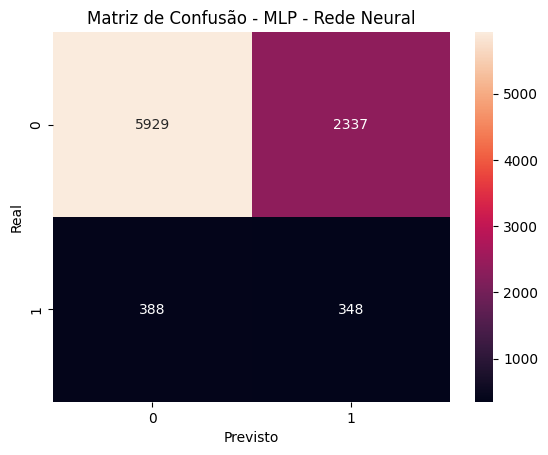

In [27]:
print("PIPELINE 6 - MLP")
modelo_mlp = MLPClassifier(hidden_layer_sizes=(30, 15), max_iter=150, early_stopping=True, random_state=42)
modelo_mlp.fit(X_train_scaled, y_train_balanced)
avaliar("MLP - Rede Neural", modelo_mlp, X_test_scaled, y_test)

# COMPARAÇÃO DOS RESULTADOS

              Modelo  Accuracy  Precision    Recall        F1
2                SVM  0.612642   0.116746  0.569293  0.193757
0      Decision Tree  0.668962   0.132613  0.550272  0.213720
1      Random Forest  0.702733   0.142066  0.523098  0.223447
4  MLP - Rede Neural  0.697289   0.129609  0.472826  0.203449
3                KNN  0.714064   0.122432  0.404891  0.188013


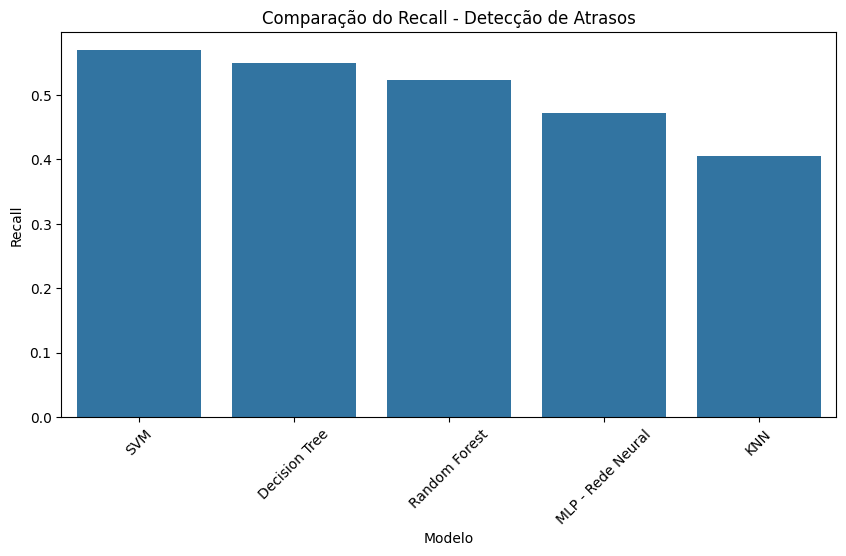

In [28]:
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(by='Recall', ascending=False)
print(df_resultados)

plt.figure(figsize=(10,5))
sns.barplot(data=df_resultados, x='Modelo', y='Recall')
plt.title("Comparação do Recall - Detecção de Atrasos")
plt.xticks(rotation=45)
plt.show()